# Challenge Clustering Analysis

This notebook explores the challenges, clusters challenges by their perceived qualities, and visualizes the resulting group structure with a radar chart. This analysis was used for Figure 3.2 in Chapter 3 in the thesis.

**Author:** Shirley Li \
**Date:** July 2026

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

### Load data
We require data on the challenges, in particular we need the mean ratings for each challenge on the following features: `usefulness`, `difficulty`, and `likedness` (enjoyment in the thesis). 

In [2]:
results_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\results\\'

data_folder = 'C:\\Users\\shirl\\Documents\\Studie\\2025-2026\\Thesis\\personalized-coping-challenges\\data\\'

action_file = 'challenge_info.csv'
actions = pd.read_csv(data_folder + action_file)

#### Radar Chart Helper

The function below draws a radar chart for comparing the cluster means across the selected clustering variables.

In [3]:
def plot_radar(labels, values, groups, title='Radar Chart'):
    """
    labels: list of strings (column names)
    values: 2D numpy array or list of lists (rows = groups, cols = labels)
    groups: list of strings (cluster/group names)
    """
    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    for i, row in enumerate(values):
        data = np.concatenate((row, [row[0]]))
        ax.plot(angles, data, linewidth=2, linestyle='solid', label=groups[i], marker='o', markersize=4)
        ax.fill(angles, data, alpha=0.25)
    ax.set_yticklabels([])
    # 5. Fix the labels
    ax.set_theta_offset(np.pi / 2) # Start at the top
    ax.set_theta_direction(-1)     # Clockwise
    
    # Set the labels for each spoke
    ax.tick_params(pad=26)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=14)
    for label in ax.get_xticklabels():
        angle = label.get_position()[0]
        if abs(angle) < 0.1 or abs(angle - 2*np.pi) < 0.1:
            label.set_y(label.get_position()[1] + 0.13)
        elif np.isclose(abs(angle), np.pi):
            label.set_y(label.get_position()[1] + 0.13)

    # Add legend and title
    # plt.title(title, size=14, y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    
    return fig, ax

### Analyze clusters

Cluster 0:
category
acceptance          5
distraction        11
problem_solving    10
social_support      2
dtype: int64

Cluster 1:
category
acceptance          7
distraction        19
problem_solving     8
social_support     11
dtype: int64

Cluster 2:
category
acceptance         12
distraction         6
problem_solving     2
social_support     10
dtype: int64



,usefulness,difficulty,likedness
cluster_all,,,
0,3.296723,3.912311,4.826503
1,3.950720,2.378977,6.062240
2,4.578884,3.536410,6.424687


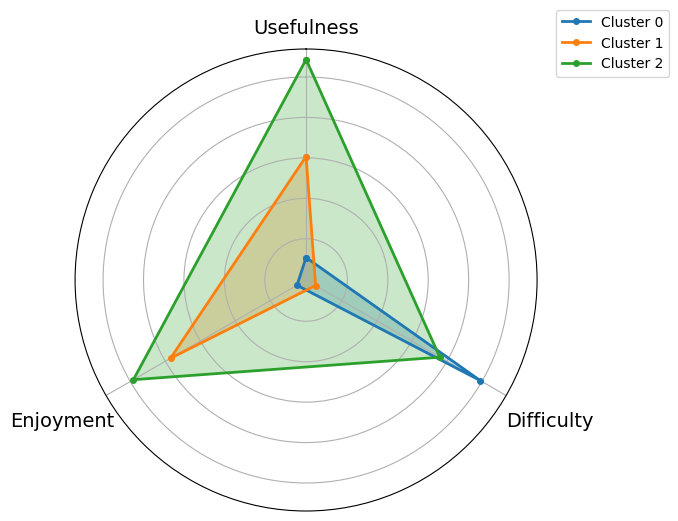

In [4]:
num_clusters = 3
cluster_col = 'cluster_all'
cluster_vars = ['usefulness', 'difficulty', 'likedness']

actions_clustered = actions.copy()
kmeans = KMeans(n_clusters=num_clusters, random_state=42)

# Scale the features before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(actions_clustered[cluster_vars])

# Perform clustering and assign cluster labels to the DataFrame
actions_clustered[cluster_col] = kmeans.fit_predict(X_scaled)

# Inspect results
means = actions_clustered.groupby(cluster_col)[cluster_vars].mean()
for cluster in range(num_clusters):
    print(f"Cluster {cluster}:")
    actions_in_cluster = actions_clustered[actions_clustered[cluster_col] == cluster]
    print(actions_in_cluster.groupby('category').size())
    print()

means = scaler.fit_transform(means)
plot_radar(labels = ['Usefulness', 'Difficulty', 'Enjoyment'], values = np.array(means), groups=["Cluster " + str(i) for i in range(num_clusters)], title='Mean Cluster Values')
plt.savefig(results_folder + "figures/cluster_radar_chart.svg", bbox_inches='tight')
actions_clustered.groupby(cluster_col)[cluster_vars].mean()